# Initial Setup

Below is the install command for the needed libraries to run the notebook

pip install scipy scikit-learn pandas seaborn shap


In [1]:
import io, math
from scipy.io import arff
from sklearn.metrics import max_error
from sklearn.metrics import mean_squared_error

import sklearn
import pandas as pd
import seaborn
import shap

c:\Users\A\OneDrive - Office 365 Fontys\Value-Investing\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data provisioning

The dataset consist of 28 columns. Ranging from 7 million to 22 million rows per column, with a total file size of 3.6gb. This immediately shows a processing problem where trying to do anything with the dataset requires alot of compute.

We can try and tackle this. By limiting the columns we actually need from the dataset. For now we gonna just take the colums that have been mentioned in the expert interview or are most closely related.

Also for these columns we dont need to load in all rows. Since the dataset contains a span of 20 years. So ideally we only want to take more recent data. For example the past 3 years.

While doing this we are gonna try and create a new filtered dataset. Consisting of fewer column and only past data rows of 3 years. That filtered dataset we will use further for our model.

# Data Dictionary
Identifiers  
Ticker: Company trading symbol  
Date: Date of the observation (price + ratios)  

Price / Market  
Adjusted Close (Target Variable): Realistic price including dividends and splits. Used for return calculations.  
Volume: Indicates market activity and sentiment around a stock.  
Market Cap: Company size. Smaller companies may have more pricing inefficiencies.  

Valuation (Core for value investing)  
P/E (ttm): Price relative to earnings. Used to assess how expensive a company is.  
P/S (ttm): Price relative to revenue. Useful when earnings are less reliable.  
P/B: Price relative to assets. Classic value investing metric.  
P/FCF (ttm): Price relative to free cash flow.  
EV/EBITDA: Measures value based on operational cash flow. Widely used by professionals.  
EV/Sales: Alternative valuation when profits are unstable.  

Value Signal  
Book to Market Value: Inverse of P/B. Indicates how “cheap” a stock is relative to its assets.  

Quality (avoid value traps).  
Operating Income/EV: Measures profitability relative to company value.  
Altman Z Score: Financial health indicator. Helps detect risk of bankruptcy.  


Optional  
Dividend Yield: Income return from dividends.  
Stakeholder mentioned dividend as an important anchor in valuation shows reliability of company.  

Data Choice  
The dataset contains both quarterly and yearly (TTM) data we will use past data of 3 years.  
For this model, TTM data is used because:

It reduces short-term noise  
It better reflects long-term earning capacity  
It aligns with how the stakeholder evaluates companies with long term vision in mind.  

In [2]:
#data column selection only exectued once to select columns
if False:
    df = pd.read_csv("us-derived-shareprices-daily/us-derived-shareprices-daily.csv")
    df.columns = df.columns.str.strip()

    print(df.columns.tolist())

Make sure we select the right columns from the initial dataset.

In [3]:
# Data filtering step (executed once to create smaller working dataset)
if False:

    # columns we want to use
    cols = [
        "Ticker", 
        "Date", 
        "Adj. Close", 
        "Volume", 
        "Market-Cap",
        "Price to Earnings Ratio (ttm)",
        "Price to Sales Ratio (ttm)",
        "Price to Book Value",
        "Price to Free Cash Flow (ttm)",
        "EV/EBITDA", 
        "EV/Sales",
        "Book to Market Value",
        "Operating Income/EV",
        "Altman Z Score",
        "Dividend Yield"
    ]

    # load only selected columns
    df = pd.read_csv(
        "us-derived-shareprices-daily/us-derived-shareprices-daily.csv",
        usecols=cols,
        sep=";"
    )

    # convert Date column
    df["Date"] = pd.to_datetime(df["Date"])

    # filter between 2022 and end of 2025
    df = df[df["Date"].between("2022-01-01", "2025-12-31")]

    # save filtered dataset
    df.to_csv("filtered_shares_ratios_3years.csv", index=False)

    print("created filtered dataset")

Created a filtered dataset reduced from 28 to 15 columns.

Since the datasets are to big to push to github and don't belong in github. Added datasets .csv, .parquet, .xslx files to gitignore.

Sample

ToDo:

data describe method gebruiken
gaten in data duidelijk in kaart brengen
duidelijk maken wat moet mee gebeuren, en waarom onderbouwing!
ene attribuut 50% andere 75%
welke attributen gebruiken en waarom

The dataset contains extreme values as outliers from -100000 to 100000 so we have to replace these otherwise they'll give a wrong image of the actual figures.

Since the dataset contains very large numbers. Pandas automatically displays them in scientific notation, we change the formatting to make it easier understandable.

In [4]:
df = pd.read_csv("filtered_shares_ratios_3years.csv")
df.describe()


,Adj. Close,Volume,Market-Cap,Price to Earnings Ratio (ttm),Price to Sales Ratio (ttm),Price to Book Value,Price to Free Cash Flow (ttm),EV/EBITDA,EV/Sales,Book to Market Value,Operating Income/EV,Altman Z Score,Dividend Yield
count,5.077223e+06,5.077223e+06,4.846845e+06,3.619868e+06,3.274182e+06,4.048688e+06,2.758179e+06,3.212294e+06,3.200910e+06,3.972041e+06,3.577781e+06,2.859125e+06,1.636477e+06
mean,2.508054e+04,1.703947e+06,4.219712e+12,-1.730331e+01,1.370486e+02,1.063825e+01,-2.022930e+01,1.040932e+00,7.648980e+01,1.096683e+01,-8.269594e+00,2.341573e+01,2.185915e+00
std,1.419652e+06,1.106200e+07,4.197879e+14,2.812195e+03,3.520416e+03,1.900016e+03,2.239674e+03,1.370573e+03,3.095022e+03,8.267660e+02,9.473802e+02,2.024572e+03,2.855518e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-3.576344e+04
25%,5.780000e+00,3.290600e+04,1.301741e+08,-3.799602e+00,7.373900e-01,7.864400e-01,-2.938540e+00,-7.300700e-01,8.751400e-01,1.875300e-01,-5.040000e-02,6.364500e-01,1.068000e-02
50%,1.626000e+01,2.620240e+05,7.850186e+08,6.453625e+00,1.953155e+00,1.616180e+00,5.291540e+00,7.518780e+00,2.221115e+00,4.889800e-01,3.346000e-02,2.211520e+00,2.341000e-02
75%,4.615000e+01,1.039564e+06,4.506176e+09,2.126395e+01,4.593700e+00,3.642730e+00,1.524451e+01,1.497710e+01,5.223825e+00,9.737800e-01,8.125000e-02,4.288110e+00,4.275000e-02
max,1.000000e+08,5.497020e+09,5.698460e+16,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,2.414675e+04


In [5]:
for col in df.select_dtypes(include="number").columns:
    df[col] = df[col].clip(
        df[col].quantile(0.01),
        df[col].quantile(0.99)
    )
#format numbers understandable
#je moet aparte format hebben voor kleine nummers decimalen en grote getallen.
pd.options.display.float_format = '{:,.0f}'.format
df.describe()

,Adj. Close,Volume,Market-Cap,Price to Earnings Ratio (ttm),Price to Sales Ratio (ttm),Price to Book Value,Price to Free Cash Flow (ttm),EV/EBITDA,EV/Sales,Book to Market Value,Operating Income/EV,Altman Z Score,Dividend Yield
count,"5,077,223","5,077,223","4,846,845","3,619,868","3,274,182","4,048,688","2,758,179","3,212,294","3,200,910","3,972,041","3,577,781","2,859,125","1,636,477"
mean,50,"1,318,200","9,906,944,521",0,23,7,4,7,12,1,-0,2,0
std,99,"3,267,110","30,027,861,698",126,131,36,91,44,58,2,1,11,0
min,0,0,0,-869,0,-55,-542,-241,-9,-3,-7,-58,-0
25%,6,"32,906","130,174,107",-4,1,1,-3,-1,1,0,-0,1,0
50%,16,"262,024","785,018,580",6,2,2,5,8,2,0,0,2,0
75%,46,"1,039,564","4,506,176,000",21,5,4,15,15,5,1,0,4,0
max,708,"23,237,622","213,724,993,671",518,"1,153",307,476,227,509,21,6,51,1


Before and after how valuable formatting visually is. Also the effects of excluding the outliers by using middle range of 95% of data.

Also there should be looked into which columns are chosen to select ranges. Cause this approach isn't applicable to each column. For example if there are businesses with huge market caps they are outliers. But them being outliers isn't bad. That's just the way it is they're just very big companies. So maybe log is more suitable.

We can use describe function to get an idea of how the dataset is structured and get an idea of possible outliers and missing values. Based on this we can make a more targeted approach on trying to find a solution to get a proper dataset to use.

You can chose ranges based of the standard devation. To try an filter out any outliers. If so much percent of the data is within a certain range (standard devation) any values outside that range can be considered outliers and removed from the dataset.


Standard devation approach doesn't work. Because the standard devation is inhertenly skewed because of the outliers, cause the std is calculated with the outliers. Filtering on percentages would be better. X% middle within range.

Now we just arbitrarely chose 95% the correct way would be to look per column at a data distribution and determine the range that way till what value of ranges it is good to include and from where it become outliers.

In [6]:
df.sample(10)
pd.options.display.float_format = '{:,.0f}'.format


From sampling and the metadata immediately becomes clear that we have alot of missing values.

!!NOT ONLY PERCENTAGES ALSO NUMBER HOW MANY MISSING VALUES!!

In [7]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing

Dividend Yield                  68
Price to Free Cash Flow (ttm)   46
Altman Z Score                  44
EV/Sales                        37
EV/EBITDA                       37
Price to Sales Ratio (ttm)      36
Operating Income/EV             30
Price to Earnings Ratio (ttm)   29
Book to Market Value            22
Price to Book Value             20
Market-Cap                       5
Ticker                           0
Volume                           0
Date                             0
Adj. Close                       0
dtype: float64

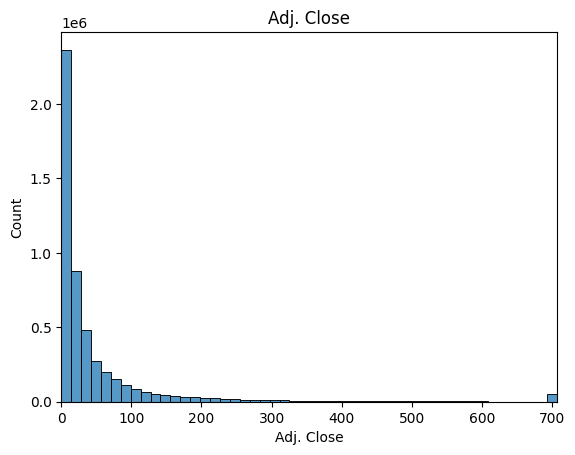

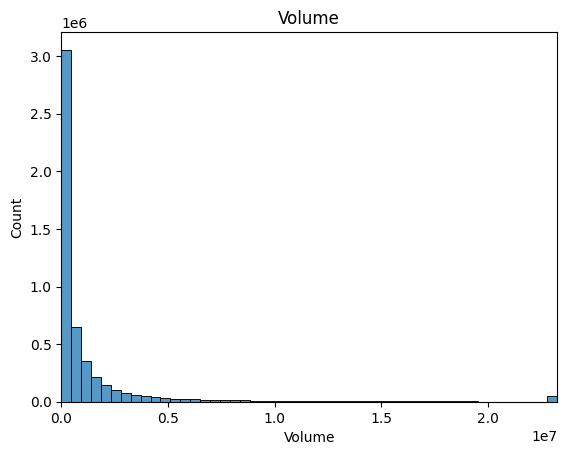

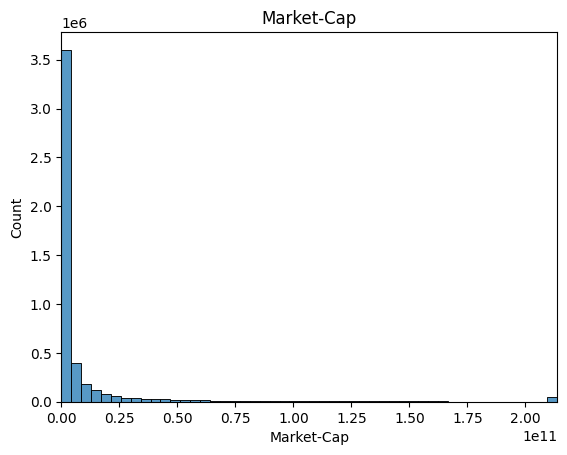

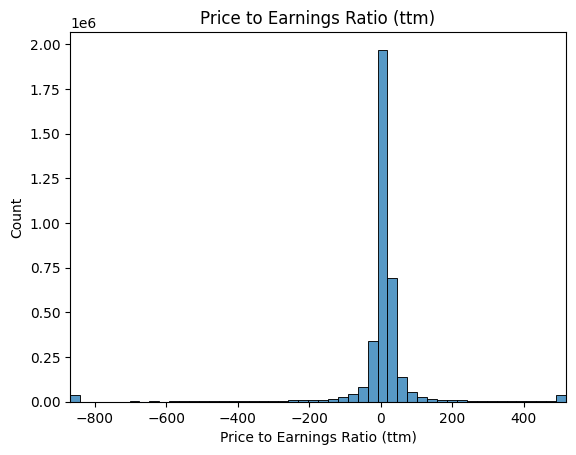

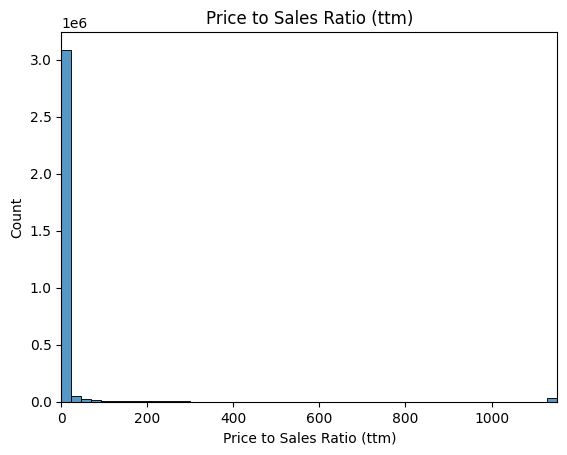

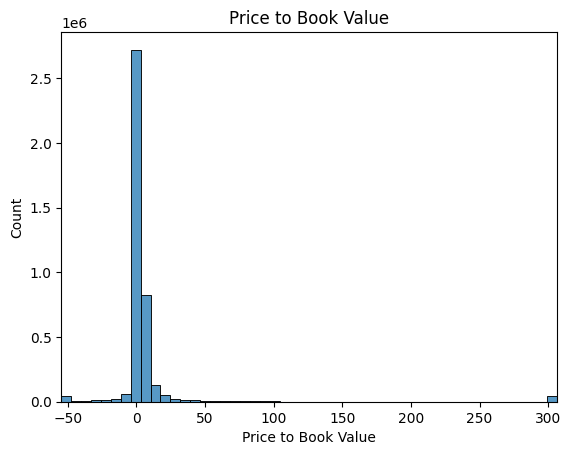

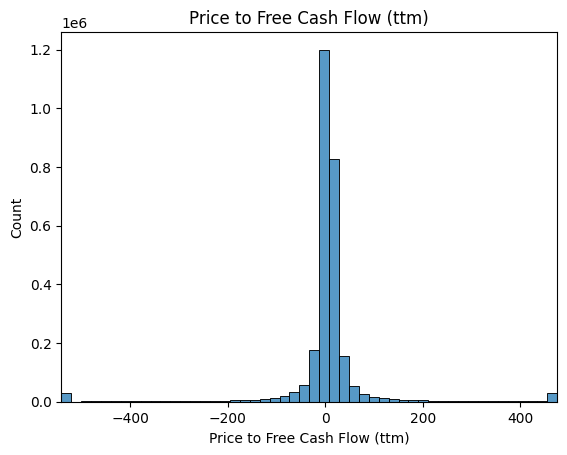

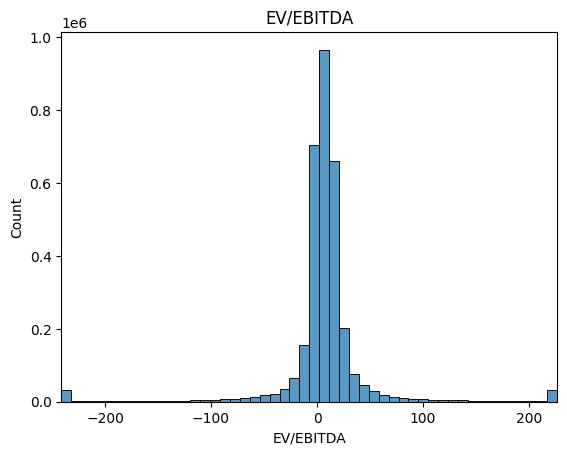

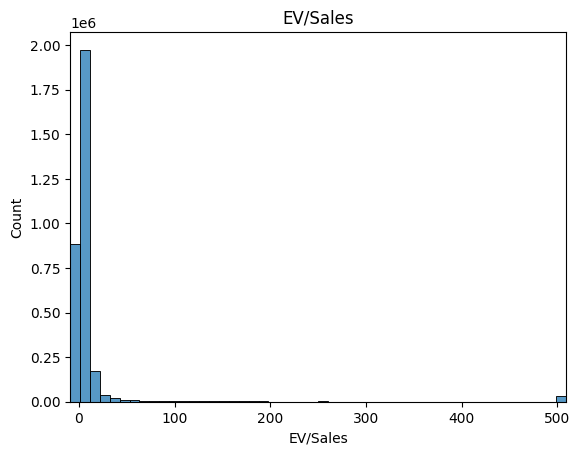

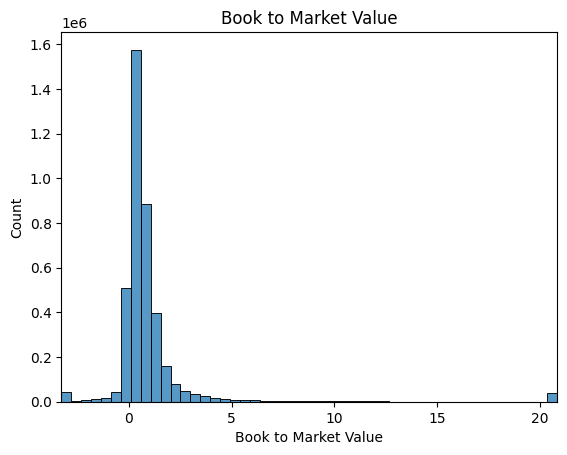

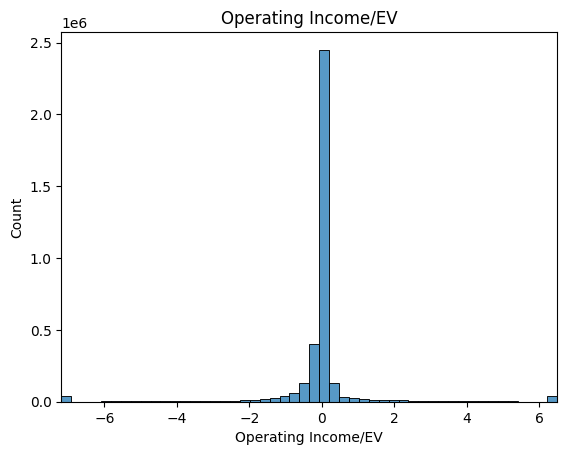

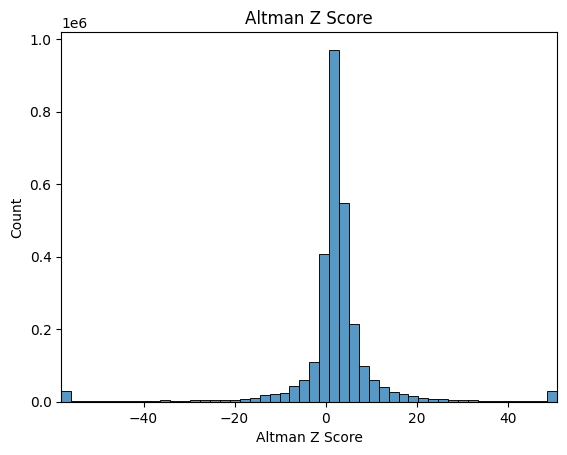

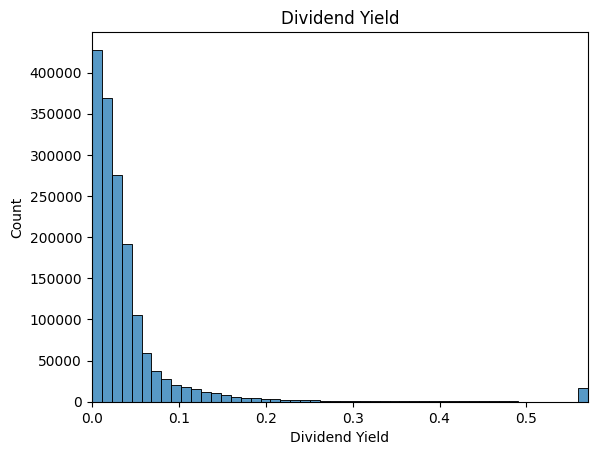

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
for col in df.select_dtypes(include="number").columns:
    plt.figure()
    sns.histplot(df[col].dropna(), bins=50)
    plt.xlim(df[col].quantile(0.01), df[col].quantile(0.99))  # 🔥 removes extreme outliers
    plt.title(col)
    plt.show()

Here we can see percentage per column of missing values. Important to note here in sampling we saw the dataset doesn't just contain missing values. But also outliers as well as incorrect values?

We can try and remove rows that have missing values. As well as remove outliers (by looking at averages or distribution or !!standard devation best!!)

Lets try and remove rows with to many missing values

# Log

Log the data to minimalize huge differences in column numbers, fix outliers and fix skew. The dataset includes colums like marketcap and EV/EBITDA and Adjusted Close price. Which include huge differences. Logging is the inverse of exponential this way it can compress datas high values making them less prominent for the model while still being included.

In a column like market cap huge differences don't mean there is anything wrong with the data or they're outliers.Especially since linear regression is sensitive to extreme values. 

Market cap contains extreme values relative to other features, and also it is a extremely skewed distribution. 
The model would put to much focus on market cap instead of other features. 

It also means there are just smaller companies and huge companies. But all values are equally important for the model to learn. However if the model were to be trained on just the regular values. The model would also put in the market cap column higher implication on market cap higher values.

In essence especially with linear regression the model will think higher values are more important.

In the above mentioned describe method it is visible why logging is interesting in this context. It shows across all ranges for values 

# Clean data

When manually going through the dataset. One thing noticable is that there are sometimes extreme value jumps between days. That given the domain are certainly just wrong values. We can try and fix these values by taking for example the average of the previous and next day.

For rows were there are just to many missing values. Putting in averages would make the model learn to much on data that doesn't exist. Also in some cases practically you shouldn't fill, if a row is missing dividend yield because the business didn't pay out dividends. Filling it would make the data lie. Cause with dividend yield based on domain knowledge from the stakeholder for example you don't just care about the number, you care about how often dividend is payed out regardless of the number that information in itself is valuable and shouldn't be manipulated.